In [63]:
# imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [64]:
# Import csv
# IMPORTANT:
# The first line of the file needs to be edited, because the raw csv from kaggle is missing a name
# If you're on a unix system, I've included a handy bash script to edit this for you.
# Otherwise, manually replace the string "About the game" with "idk,About the game"
df = pd.read_csv("games.csv")
df.head()


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,idk,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


# Data Cleaning and Processing

### Removing unimportant fields

In [67]:
df.drop(columns='Screenshots', inplace=True)
df.drop(columns='Movies', inplace=True)
df.drop(columns='About the game', inplace=True)
df.drop(columns='idk', inplace=True)
df.drop(columns='Reviews', inplace=True)
df.drop(columns='Header image', inplace=True)
df.drop(columns='Website', inplace=True)
df.drop(columns='Support url', inplace=True)
df.drop(columns='Support email', inplace=True)
df.drop(columns='Score rank', inplace=True)
df.drop(columns='Achievements', inplace=True)
df.drop(columns='Recommendations', inplace=True)
df.drop(columns='Notes', inplace=True)
df.drop(columns='Metacritic url', inplace=True)


df.head()



,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Supported languages,Full audio languages,...,Negative,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,[],[],...,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,['English'],[],...,3,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute"
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,"['English', 'French', 'German', 'Russian']",[],...,3,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec..."
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,['Korean'],['Korean'],...,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,['English'],['English'],...,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN


### Handle Missing Values

In [69]:
# Find columns with missing values
for i in df.columns:
    print(i, df[i].isna().sum())



AppID 0
Name 1
Release date 0
Estimated owners 0
Peak CCU 0
Required age 0
Price 0
DiscountDLC count 0
Supported languages 0
Full audio languages 0
Windows 0
Mac 0
Linux 0
Metacritic score 0
User score 0
Positive 0
Negative 0
Average playtime forever 0
Average playtime two weeks 0
Median playtime forever 0
Median playtime two weeks 0
Developers 8437
Publishers 8909
Categories 8953
Genres 8413
Tags 39265


In [70]:
# Fill missing values
df['Name'] = df['Name'].fillna("None")
df['Developers'] = df['Developers'].fillna("None")
df['Publishers'] = df['Publishers'].fillna("None")
df['Categories'] = df['Categories'].fillna("None")
df['Genres'] = df['Genres'].fillna("None")
df['Tags'] = df['Tags'].fillna("None")

df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,Supported languages,Full audio languages,...,Negative,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,[],[],...,0,0,0,0,0,None,None,None,None,None
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,['English'],[],...,3,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute"
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,"['English', 'French', 'German', 'Russian']",[],...,3,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec..."
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,['Korean'],['Korean'],...,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",None
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,['English'],['English'],...,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",None


### Convert Release date to datetime format

In [72]:
df['Release date'] = pd.to_datetime(df['Release date'])
df['Release date'].head()

0   2023-08-01
1   2016-07-29
2   2019-05-06
3   2024-10-31
4   2025-04-24
Name: Release date, dtype: datetime64[ns]

### Converting list strings to lists

In [74]:
df['Categories'] = df['Categories'].str.split(',')
df['Categories'].head()

0                                               [None]
1    [Single-player, Steam Trading Cards, Steam Clo...
2                      [Single-player, Family Sharing]
3    [Single-player, Steam Achievements, Family Sha...
4    [Single-player, VR Only, Steam Leaderboards, F...
Name: Categories, dtype: object

In [75]:
df['Genres'] = df['Genres'].str.split(',')
df['Genres'].head()

0                         [None]
1                    [Adventure]
2                       [Casual]
3    [Casual, Indie, Simulation]
4         [Action, Early Access]
Name: Genres, dtype: object

In [76]:
df['Tags'] = df['Tags'].str.split(',')

df['Tags'].head()

0                                               [None]
1               [Adventure, Visual Novel, Anime, Cute]
2    [Casual, Card Game, Solitaire, Puzzle, Hidden ...
3                                               [None]
4                                               [None]
Name: Tags, dtype: object

### Removing duplicates / resolving inconsistent IDs

In [78]:
df = df.drop_duplicates(subset="AppID")
df = df.drop_duplicates(subset="Name")

### Create the column, estimated_revenue

In [80]:
def midpoint(owner_range):
    low, high = owner_range.split(" - ")
    return (int(low) + int(high)) / 2

df["estimated_owners_mid"] = df["Estimated owners"].apply(midpoint)
df["estimated_revenue"] = df["estimated_owners_mid"] * df["Price"]
df['estimated_revenue'].head()

0        0.0
1    52400.0
2    49900.0
3    89900.0
4    49900.0
Name: estimated_revenue, dtype: float64

# Part 5: Exploratory Data Analysis Tasks

### Correlation between Number of languages and estimated_revenue

In [83]:
def count_languages(supported_languages):
    if pd.isna(supported_languages) or supported_languages == "[]":
        return 0
    # Remove brackets and quotes, then split by comma
    clean_str = supported_languages.strip("[]").replace("'", "")
    languages = clean_str.split(",") if clean_str else []
    return len(languages)

df["num_languages"] = df["Supported languages"].apply(count_languages)
df["num_languages"].head()


0    0
1    1
2    4
3    1
4    1
Name: num_languages, dtype: int64

In [84]:
print("correlation between languages and revenue: " + str(df["num_languages"].corr(df["estimated_revenue"])))

correlation between languages and revenue: 0.012264295601365296


### Correlation between Number of languages and estimated_owners

In [86]:
print("correlation between languages and owners: " + str(df["num_languages"].corr(df["estimated_owners_mid"])))

correlation between languages and owners: 0.02517177536489222


### Numbers Sold per Operating System 

In [88]:
# get counts for number of games each
# This works because True is 1 and False is 0
win_count_games = df['Windows'].sum()
linux_count_games = df['Linux'].sum()
mac_count_games = df['Mac'].sum()

print("~~~ Number of Games ~~~")
print("Windows: ", win_count_games)
print("Linux:   ", linux_count_games)
print("MacOS:   ", mac_count_games)

# Obtain sums of each type
win_count_sold = df.loc[df['Windows'] == True, 'estimated_owners_mid'].sum()
linux_count_sold = df.loc[df['Linux'] == True, 'estimated_owners_mid'].sum()
mac_count_sold = df.loc[df['Mac'] == True, 'estimated_owners_mid'].sum()

print("\n~~~ Estimated Copies Sold ~~~")
print("Windows: ", win_count_sold)
print("Linux:   ", linux_count_sold)
print("MacOS:   ", mac_count_sold)

print("\n~~~ Ratio ~~~")
print("Windows: ", win_count_sold / win_count_games)
print("Linux:   ", linux_count_sold / linux_count_games)
print("MacOS:   ", mac_count_sold / mac_count_games)





~~~ Number of Games ~~~
Windows:  121411
Linux:    15535
MacOS:    21076

~~~ Estimated Copies Sold ~~~
Windows:  10331835000.0
Linux:    2568570000.0
MacOS:    3109710000.0

~~~ Ratio ~~~
Windows:  85098.01418322886
Linux:    165340.84325716124
MacOS:    147547.44733345986


### Correlation Between Price and Copies Sold

In [90]:
print("Correlation between price and estimated owners: " + str(df["Price"].corr(df["estimated_owners_mid"])))

Correlation between price and estimated owners: 0.012512392181274418


### Count Estimated Owners and Price (This is used to help understand the values we're working with.)

In [92]:
print(df["Estimated owners"].value_counts())
print("\n Values for Price simply display the top 5 most common prices and all others till least common.")
print(df["Price"].value_counts())

Estimated owners
0 - 20000                74670
0 - 0                    21455
20000 - 50000            11297
50000 - 100000            5305
100000 - 200000           3422
200000 - 500000           2834
500000 - 1000000          1145
1000000 - 2000000          717
2000000 - 5000000          398
5000000 - 10000000         120
10000000 - 20000000         49
20000000 - 50000000         30
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

 Values for Price simply display the top 5 most common prices and all others till least common.
Price
0.00     25946
0.99      8796
4.99      8016
1.99      6564
2.99      6276
         ...  
19.94        1
18.69        1
2.17         1
8.36         1
2.76         1
Name: count, Length: 939, dtype: int64


### Aggregation Between Price (increasing by $5s) and Estimated_Owners

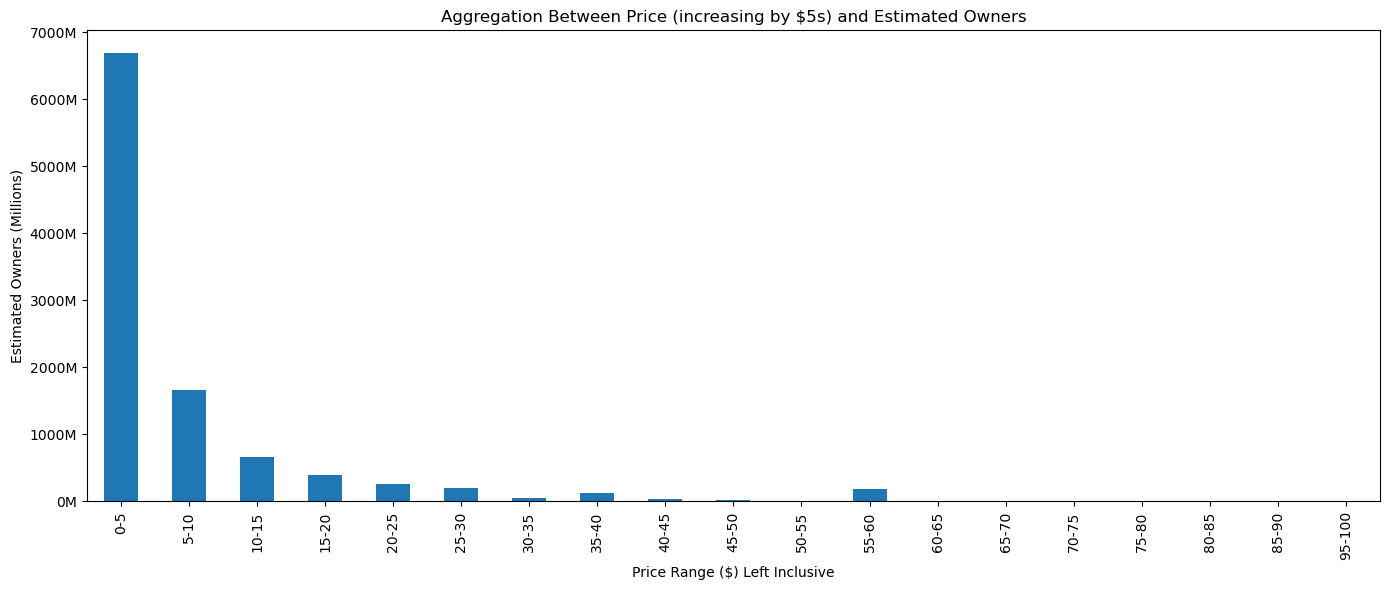

In [94]:
binsof5 = list(range(0, 105, 5))
labelsfor5 = [f"{i}-{i+5}" for i in binsof5[:-1]]
df["pricebins5"] = pd.cut(df["Price"], bins = binsof5, labels = labelsfor5, right = False)

groupsof5 = df.groupby("pricebins5", observed = True)["estimated_owners_mid"].sum()

def millions(x, _):
    return f"{x/1_000_000:.0f}M"

plt.figure(figsize=(14, 6))
groupsof5.plot(kind = "bar")
plt.title("Aggregation Between Price (increasing by $5s) and Estimated Owners")
plt.xlabel("Price Range ($) Left Inclusive")
plt.ylabel("Estimated Owners (Millions)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(millions))
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

### Aggregation Between Price (increasing by $10s) and Estimated_Owne

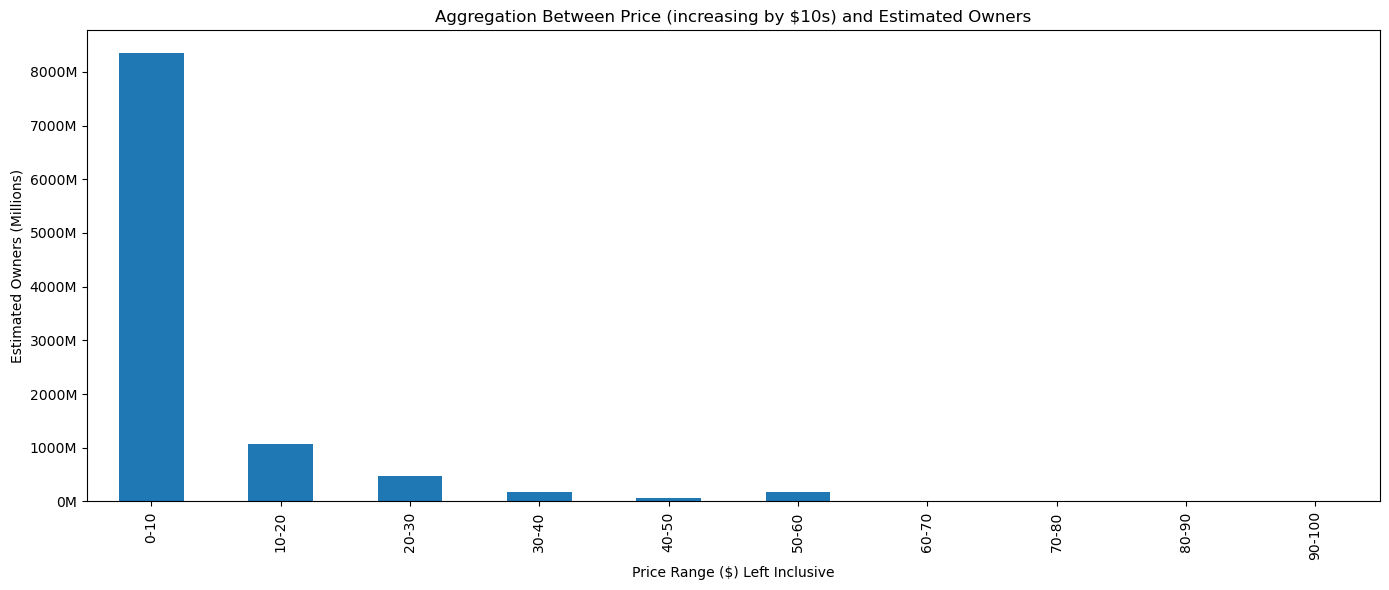

In [96]:
binsof10 = list(range(0, 110, 10))
labelsfor10 = [f"{i}-{i+10}" for i in binsof10[:-1]]
df["pricebins10"] = pd.cut(df["Price"], bins = binsof10, labels = labelsfor10, right = False)

groupsof10 = df.groupby("pricebins10", observed = True)["estimated_owners_mid"].sum()

def millions(x, _):
    return f"{x/1_000_000:.0f}M"

plt.figure(figsize = (14, 6))
groupsof10.plot(kind = "bar")
plt.title("Aggregation Between Price (increasing by $10s) and Estimated Owners")
plt.xlabel("Price Range ($) Left Inclusive")
plt.ylabel("Estimated Owners (Millions)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(millions))
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

### Genre Count in both Bar and Piechart

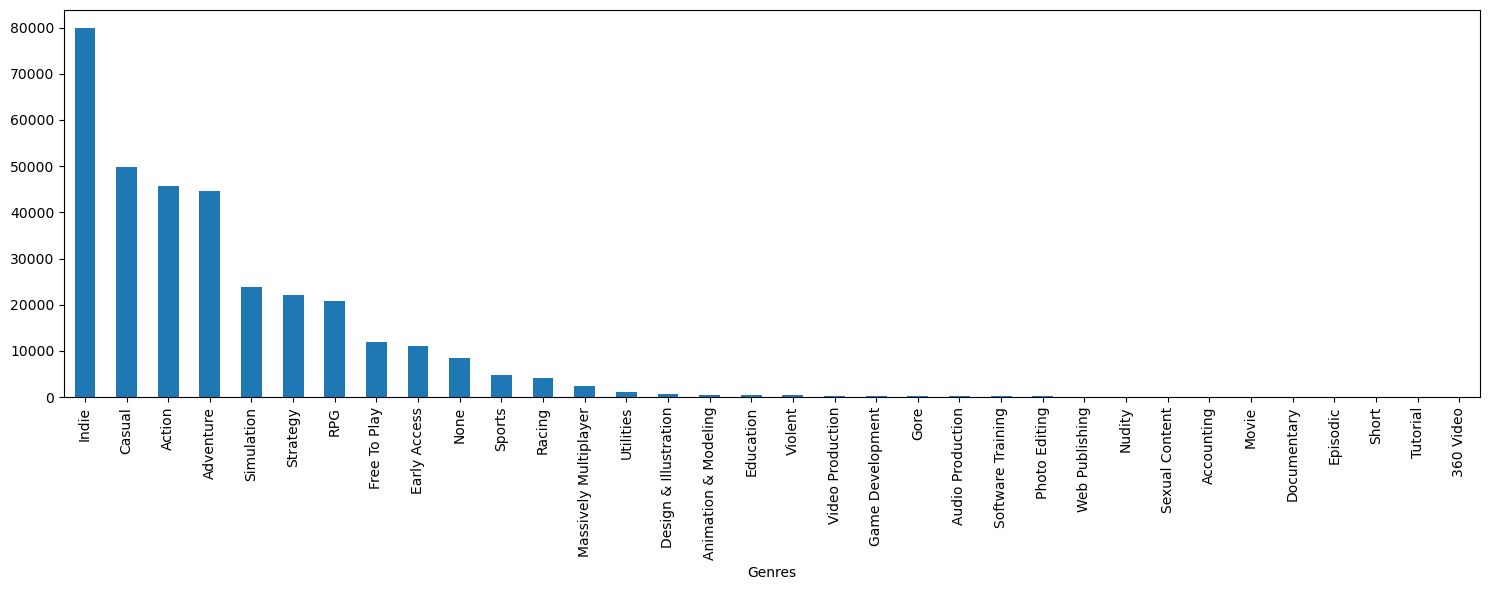

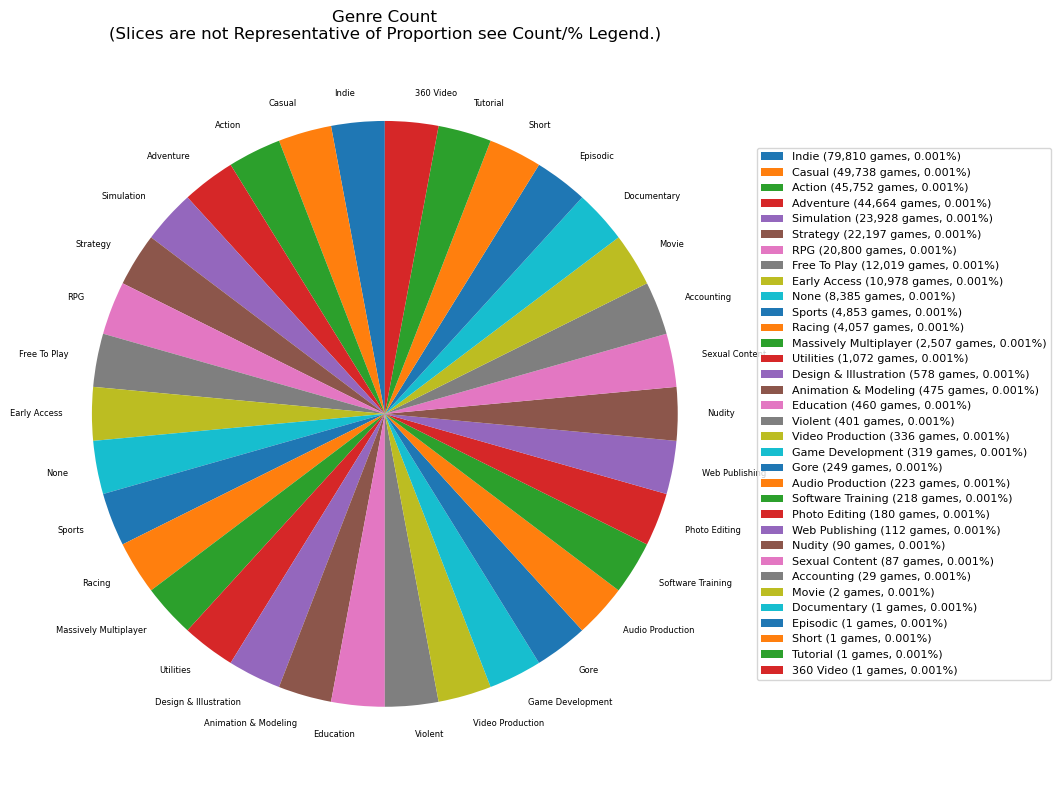

In [98]:
genre_counts = df["Genres"].explode().str.strip().value_counts()

plt.figure(figsize = (15, 6))
genre_counts.plot(kind = "bar")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

labels = []
for genre, count in genre_counts.items():
    count / genre_counts.sum() * 100
    labels.append(f"{genre} ({count:,} games, {pct:.3f}%)")

plt.figure(figsize=(10, 8))
patches, texts = plt.pie([1] * len(genre_counts),
    labels = list(genre_counts.index),
    labeldistance = 1.1,
    startangle = 90,
    textprops = {"fontsize": 6})

plt.legend(patches, labels, loc = "center left", bbox_to_anchor = (1, 0.5), fontsize = 8)
plt.title("Genre Count\n(Slices are not Representative of Proportion see Count/% Legend.)")
plt.tight_layout()
plt.show()

### Piechart of Required Age for Games

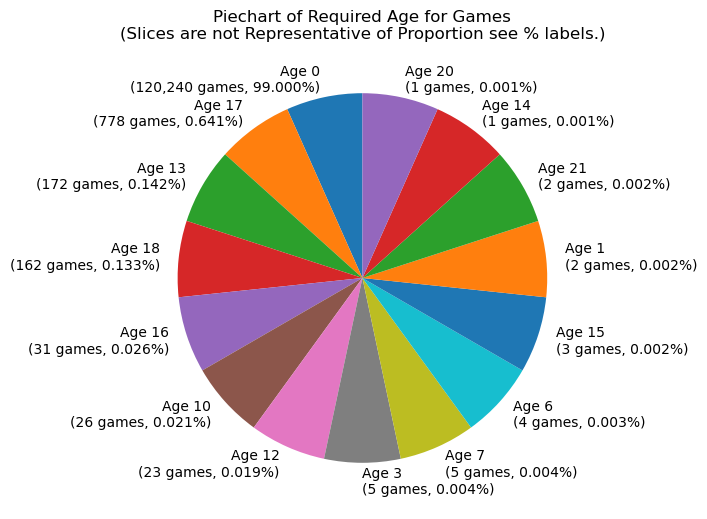

In [100]:
age_counts = df["Required age"].value_counts()

labels = []
for age, count in age_counts.items():
    pct = count / len(df) * 100
    labels.append(f"Age {age}\n({count:,} games, {pct:.3f}%)")

plt.figure(figsize=(6, 6))
plt.pie([1] * len(age_counts),
        labels = labels,
        startangle = 90)
plt.title("Piechart of Required Age for Games\n(Slices are not Representative of Proportion see % labels.)")
plt.show()